# PB1-9: Correlation of Weather Parameters with Wind Power

This notebook compares offshore wind speed, KNMI weather data, and wind power output.

Main goal: show how power output changes at different wind speeds.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd()

SEARCH_FOLDERS = [
    BASE_DIR,
    BASE_DIR / "datasets",
    BASE_DIR.parent / "datasets",
    BASE_DIR.parent,
]

def find_file(filename):
    for folder in SEARCH_FOLDERS:
        path = folder / filename
        if path.exists():
            return path
    return None

print("Notebook folder:", BASE_DIR)

Notebook folder: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main\Offshore_Wind_Energy_Forecasting-main\Comparison_KNMIvOffShore


## 1. Load offshore wind farm data

These files contain wind speed and power output for different offshore wind farms.

In [2]:
def load_offshore():
    files = [
        "offshore_Gemini.csv",
        "offshore_Borssele_12.csv",
        "offshore_Borssele_34.csv",
        "offshore_Hollandse_Kust_Zuid.csv",
        "offshore_Hollandse_Kust_Noord.csv"
    ]

    dfs = []

    for filename in files:
        path = find_file(filename)

        if path is None:
            print(f"Missing offshore file: {filename}")
            continue

        df = pd.read_csv(path)
        print(f"Loaded: {path}")
        print(df.columns)

        df["timestamp"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.rename(columns={"Power": "power"})

        df = df[["timestamp", "Windspeed", "power", "Station"]]
        df = df.dropna()

        dfs.append(df)

    if len(dfs) == 0:
        raise FileNotFoundError("No offshore CSV files were found.")

    return pd.concat(dfs, ignore_index=True)

offshore = load_offshore()

print("\nCombined offshore shape:")
print(offshore.shape)

offshore.head()

Loaded: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main\Offshore_Wind_Energy_Forecasting-main\datasets\offshore_Gemini.csv
Index(['time', 'Windspeed', 'Scaled_Windspeed_(at_120m)', 'Wind_Direction',
       'Turn_off', 'Power', 'Station'],
      dtype='str')
Loaded: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main\Offshore_Wind_Energy_Forecasting-main\datasets\offshore_Borssele_12.csv
Index(['time', 'Windspeed', 'Scaled_Windspeed_(at_116.5m)', 'Wind_Direction',
       'Turn_off', 'Power', 'Station'],
      dtype='str')
Loaded: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main\Offshore_Wind_Energy_Forecasting-main\datasets\offshore_Borssele_34.csv
Index(['time', 'Windspeed', 'Scaled_Windspeed_(at_100m)', 'Wind_Direction',
       'Turn_off', 'Power', 'Station'],
      dtype='str')
Loaded: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main\Offshore_Wind_Energy_Forecasting-main\datasets\offshore_Hollandse_Kust_Zuid.csv
Index(['time', 'Wi

,timestamp,Windspeed,power,Station
0,1980-01-01 00:00:00,11.920606,600.0,Gemini
1,1980-01-01 01:00:00,11.360207,600.0,Gemini
2,1980-01-01 02:00:00,11.575466,600.0,Gemini
3,1980-01-01 03:00:00,12.431805,600.0,Gemini
4,1980-01-01 04:00:00,13.136039,600.0,Gemini


## 2. Average power output at different offshore wind speeds

This is the clearest graph for PB1-9. Instead of plotting every raw point, we group wind speeds into rounded bins and calculate the average power output.

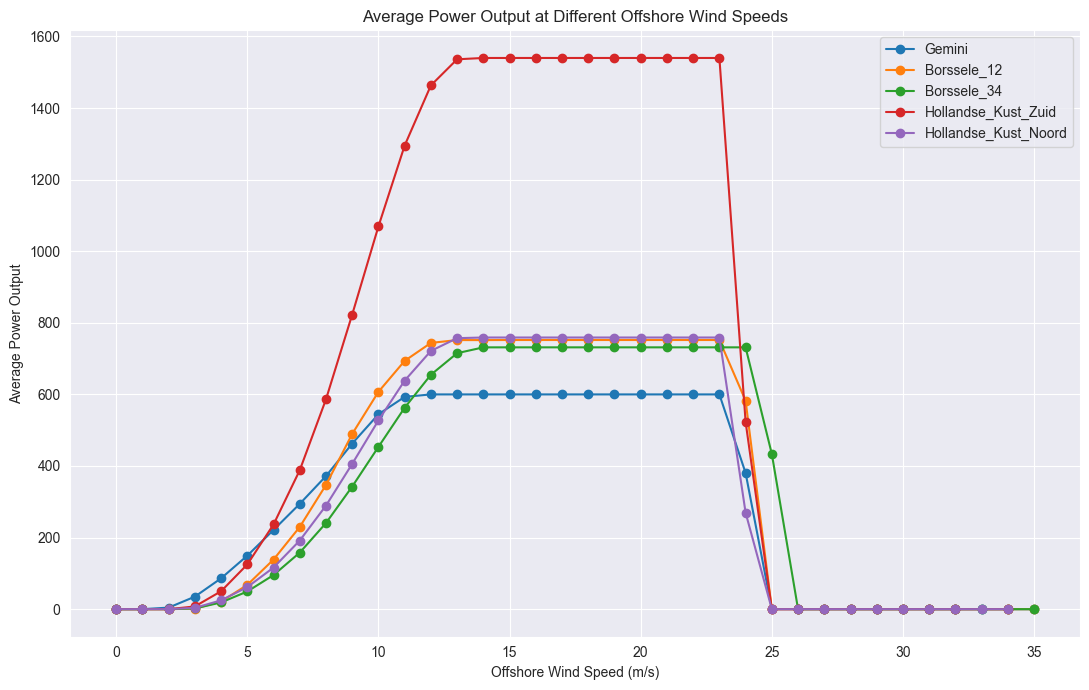

In [3]:
plt.figure(figsize=(11, 7))

for station in offshore["Station"].unique():
    station_data = offshore[offshore["Station"] == station].copy()
    station_data["wind_speed_bin"] = station_data["Windspeed"].round(0)

    average_power = (
        station_data
        .groupby("wind_speed_bin")["power"]
        .mean()
        .reset_index()
    )

    plt.plot(
        average_power["wind_speed_bin"],
        average_power["power"],
        marker="o",
        label=station
    )

plt.xlabel("Offshore Wind Speed (m/s)")
plt.ylabel("Average Power Output")
plt.title("Average Power Output at Different Offshore Wind Speeds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Load KNMI weather data

KNMI is used to compare weather station wind speed with offshore power output.

In [4]:
def load_knmi():
    path = find_file("knmi_209_2011_2020_cleaned.csv")

    if path is None:
        print("KNMI file not found.")
        return None

    df = pd.read_csv(path)
    print(f"Loaded KNMI file: {path}")
    print(df.columns)

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    df = df[
        [
            "timestamp",
            "wind_speed_ms",
            "wind_gust_ms",
            "temperature_c",
            "pressure_hpa",
            "humidity_pct",
            "precipitation_mm"
        ]
    ]

    return df

knmi = load_knmi()

if knmi is not None:
    display(knmi.head())

Loaded KNMI file: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main\Offshore_Wind_Energy_Forecasting-main\Comparison_KNMIvOffShore\knmi_209_2011_2020_cleaned.csv
Index(['timestamp', 'wind_direction_deg', 'wind_speed_ms',
       'wind_speed_10min_ms', 'wind_gust_ms', 'temperature_c', 'pressure_hpa',
       'humidity_pct', 'precipitation_mm'],
      dtype='str')


,timestamp,wind_speed_ms,wind_gust_ms,temperature_c,pressure_hpa,humidity_pct,precipitation_mm
0,2011-01-01 02:00:00,7.0,9.0,NaN,NaN,NaN,NaN
1,2011-01-01 03:00:00,7.0,9.0,NaN,NaN,NaN,NaN
2,2011-01-01 04:00:00,8.0,9.0,NaN,NaN,NaN,NaN
3,2011-01-01 05:00:00,7.0,9.0,NaN,NaN,NaN,NaN
4,2011-01-01 06:00:00,7.0,8.0,NaN,NaN,NaN,NaN


## 4. KNMI wind speed compared with offshore power

This graph checks whether KNMI measured wind speed follows a similar pattern to offshore wind power output.

Merged KNMI + offshore shape:
(383070, 10)


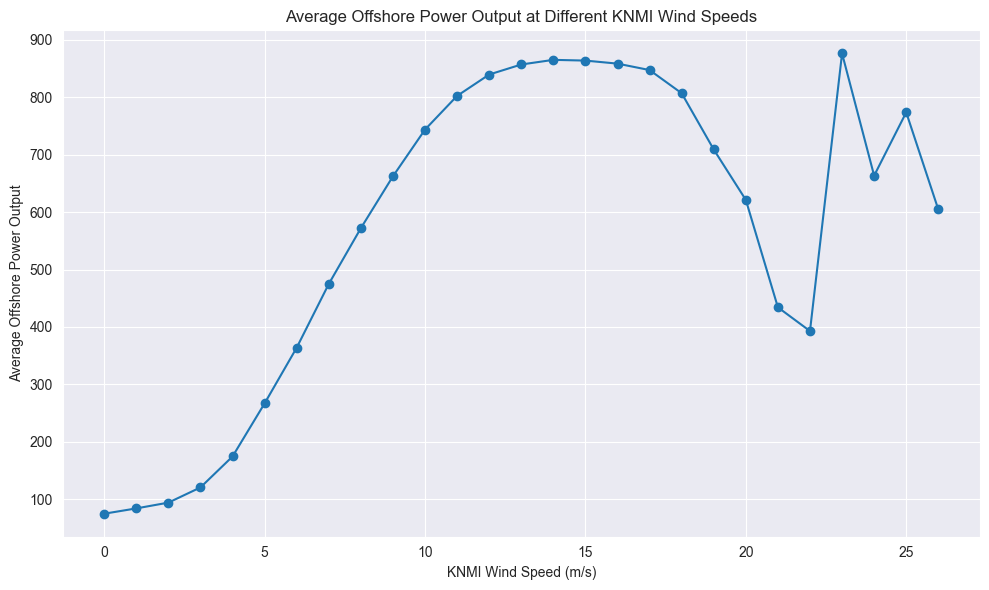

In [5]:
if knmi is not None:
    merged = pd.merge(
        offshore,
        knmi,
        on="timestamp",
        how="inner"
    )

    print("Merged KNMI + offshore shape:")
    print(merged.shape)

    if not merged.empty:
        merged["knmi_wind_speed_bin"] = merged["wind_speed_ms"].round(0)

        knmi_average_power = (
            merged
            .groupby("knmi_wind_speed_bin")["power"]
            .mean()
            .reset_index()
        )

        plt.figure(figsize=(10, 6))

        plt.plot(
            knmi_average_power["knmi_wind_speed_bin"],
            knmi_average_power["power"],
            marker="o"
        )

        plt.xlabel("KNMI Wind Speed (m/s)")
        plt.ylabel("Average Offshore Power Output")
        plt.title("Average Offshore Power Output at Different KNMI Wind Speeds")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("KNMI and offshore timestamps did not overlap.")

## 5. Correlation with weather parameters

This shows which KNMI weather parameters have the strongest relationship with offshore power.

Correlation with offshore power:
wind_speed_ms      NaN
wind_gust_ms       NaN
temperature_c      NaN
pressure_hpa       NaN
humidity_pct       NaN
precipitation_mm   NaN
power              NaN
Name: power, dtype: float64


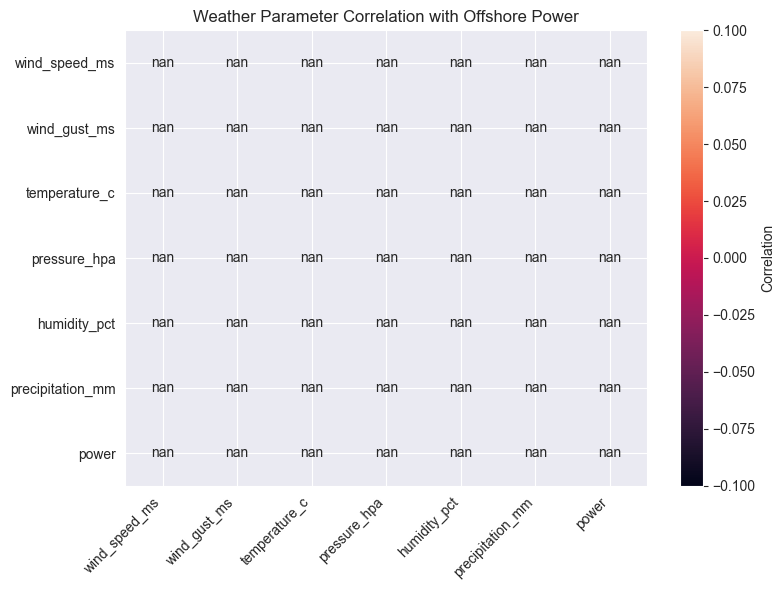

In [6]:
if knmi is not None and "merged" in globals() and not merged.empty:
    weather_columns = [
        "wind_speed_ms",
        "wind_gust_ms",
        "temperature_c",
        "pressure_hpa",
        "humidity_pct",
        "precipitation_mm"
    ]

    correlation_data = merged[weather_columns + ["power"]].dropna()
    correlation_matrix = correlation_data.corr()

    print("Correlation with offshore power:")
    print(correlation_matrix["power"].sort_values(ascending=False))

    plt.figure(figsize=(8, 6))
    plt.imshow(correlation_matrix, aspect="auto")

    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns
    )

    for i in range(len(correlation_matrix.columns)):
        for j in range(len(correlation_matrix.columns)):
            value = correlation_matrix.iloc[i, j]
            plt.text(j, i, f"{value:.2f}", ha="center", va="center")

    plt.colorbar(label="Correlation")
    plt.title("Weather Parameter Correlation with Offshore Power")
    plt.tight_layout()
    plt.show()

## 6. ENTSO comparison

ENTSO data is usually not the same type of data as offshore wind speed data. It is often used for production or installed capacity trends rather than direct wind-speed-to-power comparison.

This section will only run if an ENTSO CSV with expected columns is available.

Loaded ENTSO file: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main\Offshore_Wind_Energy_Forecasting-main\datasets\ENTSO_installed_capacity_offshore.csv
Index(['year', 'total_installed_capacity_MW', 'Borssele_34',
       'Hollandse_Kust_Zuid', 'Hollandse_Kust_Noord', 'Gemini', 'Borssele_12',
       'Others'],
      dtype='str')


,year,total_installed_capacity_MW,Borssele_34,Hollandse_Kust_Zuid,Hollandse_Kust_Noord,Gemini,Borssele_12,Others
0,2015,228.0,0.0,0.0,0.0,0.0,0.0,108.0
1,2016,957.0,0.0,0.0,0.0,0.0,0.0,252.0
2,2017,957.0,0.0,0.0,0.0,0.0,0.0,252.0
3,2018,957.0,0.0,0.0,0.0,600.0,0.0,252.0
4,2019,957.0,0.0,0.0,0.0,600.0,0.0,252.0


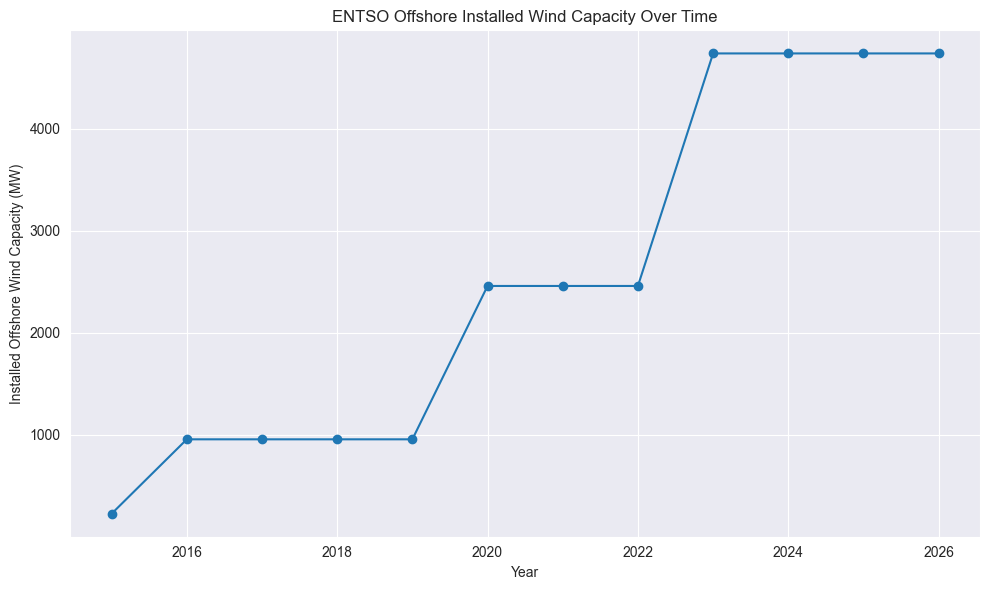

In [7]:
possible_entso_files = [
    "ENTSO_installed_capacity_offshore.csv",
    "entso_installed_capacity_offshore.csv",
    "entso.csv",
    "ENTSO.csv"
]

entso_path = None

for filename in possible_entso_files:
    entso_path = find_file(filename)
    if entso_path is not None:
        break

if entso_path is not None:
    entso = pd.read_csv(entso_path)
    print(f"Loaded ENTSO file: {entso_path}")
    print(entso.columns)

    display(entso.head())

    if "year" in entso.columns and "total_installed_capacity_MW" in entso.columns:
        plt.figure(figsize=(10, 6))
        plt.plot(entso["year"], entso["total_installed_capacity_MW"], marker="o")
        plt.xlabel("Year")
        plt.ylabel("Installed Offshore Wind Capacity (MW)")
        plt.title("ENTSO Offshore Installed Wind Capacity Over Time")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("ENTSO file found, but expected columns were not found.")
else:
    print("No ENTSO CSV file found. This section is skipped.")

In [11]:
print(knmi.head())
print(knmi.dtypes)

            timestamp  wind_speed_ms  wind_gust_ms  temperature_c  \
0 2011-01-01 02:00:00            7.0           9.0            NaN   
1 2011-01-01 03:00:00            7.0           9.0            NaN   
2 2011-01-01 04:00:00            8.0           9.0            NaN   
3 2011-01-01 05:00:00            7.0           9.0            NaN   
4 2011-01-01 06:00:00            7.0           8.0            NaN   

   pressure_hpa  humidity_pct  precipitation_mm  
0           NaN           NaN               NaN  
1           NaN           NaN               NaN  
2           NaN           NaN               NaN  
3           NaN           NaN               NaN  
4           NaN           NaN               NaN  
timestamp           datetime64[us]
wind_speed_ms              float64
wind_gust_ms               float64
temperature_c              float64
pressure_hpa               float64
humidity_pct               float64
precipitation_mm           float64
dtype: object


## PB1-9 conclusion

The offshore wind farm graph compares average power output at different wind speeds. This is clearer than a raw scatterplot because the data is grouped into wind speed bins.

The main expected pattern is that power output generally increases as wind speed increases. However, each wind farm has a different maximum output capacity, so the lines may plateau at different levels.

The KNMI comparison shows whether wind speed measured at the KNMI station follows a similar trend when compared with offshore wind power production.

ENTSO is different because it is usually useful for comparing broader production or installed capacity trends, not direct hourly wind speed against hourly power output.